# Actividad 5: Clustering with K-means
## Héctor Arturo Hernández Escalante
### Profesor: Dr. Victor Uc
### Maestría en Ciencias de la Computación
### Segundo Semestre
### Universidad Autónoma de Yucatán
### 20 de Mayo 2026


### 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

### 2. Data Loading

In [2]:
data = pd.read_csv("../datasets/Wholesale customers data.csv")
data.head()


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


### 3. Data Preprocessing
#### 3.1 Feature and Target Separation
The 'Region' column is often used as a label, but for clustering, we primarily focus on the features. We'll separate it nonetheless.

In [3]:
# Separate features and target
X = data.drop('Region', axis=1)
y = data['Region']

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)


Features (X) shape: (440, 7)
Target (y) shape: (440,)


#### 3.2 Feature Standardization
We use `StandardScaler` to standardize the features so they have a mean of 0 and a variance of 1.

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame for better visualization
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled_df.head()


,Channel,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,1.448652,0.052933,0.523568,-0.041115,-0.589367,-0.043569,-0.066339
1,1.448652,-0.391302,0.544458,0.170318,-0.270136,0.086407,0.089151
2,1.448652,-0.447029,0.408538,-0.028157,-0.137536,0.133232,2.243293
3,-0.690297,0.100111,-0.624020,-0.392977,0.687144,-0.498588,0.093411
4,1.448652,0.840239,-0.052396,-0.079356,0.173859,-0.231918,1.299347


### 4. K-means Implementation (Lloyd's Algorithm)
#### 4.1 K-means Class

In [5]:
class KMeans:
    """
    K-means clustering implementation from scratch using Lloyd's algorithm.
    """
    def __init__(self, k=3, max_iters=100, tol=1e-4):
        """
        Initializes the KMeans model.

        Args:
            k (int): Number of clusters.
            max_iters (int): Maximum number of iterations.
            tol (float): Tolerance for centroid movement stopping criterion.
        """
        self.k = k
        self.max_iters = max_iters
        self.tol = tol
        self.centroids = None
        self.labels = None
        self.inertia_ = None
        self.n_iter_ = 0

    def _euclidean_distance(self, x1, x2):
        """
        Calculates the Euclidean distance between two points.
        """
        return np.sqrt(np.sum((x1 - x2)**2))

    def fit(self, X):
        """
        Fits the K-means model to the data using a single initialization.

        Args:
            X (numpy.ndarray): Feature matrix.
        """
        n_samples, n_features = X.shape

        # 1. Initialize centroids randomly from the dataset
        random_indices = np.random.choice(n_samples, self.k, replace=False)
        self.centroids = X[random_indices]
        self.labels = np.zeros(n_samples)
        self.n_iter_ = 0

        for i in range(self.max_iters):
            self.n_iter_ += 1
            # 2. Assignment Step: Assign samples to nearest centroids
            old_labels = self.labels.copy()
            self.labels = self._get_labels(X)

            # Stopping criterion a): No assignment changes
            if np.array_equal(self.labels, old_labels):
                break

            # 3. Update Step: Calculate new centroids
            old_centroids = self.centroids.copy()
            self.centroids = self._get_centroids(X, self.labels, n_features)

            # Stopping criterion b): Centroid movement < tolerance
            distances = [self._euclidean_distance(old_centroids[j], self.centroids[j]) for j in range(self.k)]
            if max(distances) < self.tol:
                break
        
        # Calculate inertia
        self.inertia_ = self._calculate_inertia(X)

    def fit_n_runs(self, X, n_init=10):
        """
        Runs the K-means algorithm multiple times and keeps the best result.

        Args:
            X (numpy.ndarray): Feature matrix.
            n_init (int): Number of time the k-means algorithm will be run with different centroid seeds.
        """
        best_inertia = float('inf')
        best_centroids = None
        best_labels = None
        best_n_iter = 0

        for _ in range(n_init):
            self.fit(X)
            if self.inertia_ < best_inertia:
                best_inertia = self.inertia_
                best_centroids = self.centroids.copy()
                best_labels = self.labels.copy()
                best_n_iter = self.n_iter_
        
        self.inertia_ = best_inertia
        self.centroids = best_centroids
        self.labels = best_labels
        self.n_iter_ = best_n_iter

    def _calculate_inertia(self, X):
        """
        Calculates the within-cluster sum of squares.
        """
        inertia = 0
        for i, x in enumerate(X):
            centroid = self.centroids[self.labels[i]]
            inertia += np.sum((x - centroid)**2)
        return inertia

    def _get_labels(self, X):
        """
        Assigns labels based on the closest centroid.
        """
        labels = []
        for x in X:
            distances = [self._euclidean_distance(x, centroid) for centroid in self.centroids]
            labels.append(np.argmin(distances))
        return np.array(labels)

    def _get_centroids(self, X, labels, n_features):
        """
        Calculates new centroids as the mean of assigned samples.
        """
        centroids = np.zeros((self.k, n_features))
        for idx in range(self.k):
            cluster_samples = X[labels == idx]
            if len(cluster_samples) > 0:
                centroids[idx] = np.mean(cluster_samples, axis=0)
            else:
                # If a cluster is empty, keep the previous centroid or re-initialize
                centroids[idx] = self.centroids[idx]
        return centroids

    def predict(self, X):
        """
        Predicts the cluster for a given set of samples.
        """
        return self._get_labels(X)


### 5. Execution and Experiments
#### 5.1 Running experiments for k = 2, 3, 4, 5
We run the K-means algorithm for different values of $k$ and perform 10 random initializations for each to find the best run (minimum inertia).

In [6]:
k_values = [2, 3, 4, 5]
results = {}

for k in k_values:
    print(f"Running K-means for k={k}...")
    kmeans = KMeans(k=k, max_iters=300)
    kmeans.fit_n_runs(X_scaled, n_init=10)
    
    results[k] = {
        'inertia': kmeans.inertia_,
        'centroids': kmeans.centroids,
        'labels': kmeans.labels,
        'n_iter': kmeans.n_iter_
    }
    print(f"Best inertia for k={k}: {kmeans.inertia_:.4f}")
    print(f"Iterations for best run (k={k}): {kmeans.n_iter_}")

# Convert results to a DataFrame for display
results_df = pd.DataFrame([{'k': k, 'Best Inertia': results[k]['inertia'], 'Iterations': results[k]['n_iter']} for k in k_values])
print("\nSummary of results:")
print(results_df)


Running K-means for k=2...
Best inertia for k=2: 2161.8177
Iterations for best run (k=2): 15
Running K-means for k=3...
Best inertia for k=3: 1729.5107
Iterations for best run (k=3): 8
Running K-means for k=4...
Best inertia for k=4: 1430.3947
Iterations for best run (k=4): 13
Running K-means for k=5...
Best inertia for k=5: 1155.0438
Iterations for best run (k=5): 14

Summary of results:
   k  Best Inertia  Iterations
0  2   2161.817721          15
1  3   1729.510730           8
2  4   1430.394746          13
3  5   1155.043776          14


#### 5.2 Elbow and Silhouette Method Visualization
We plot the best inertia and silhouette score for each $k$ to choose the optimal number of clusters.

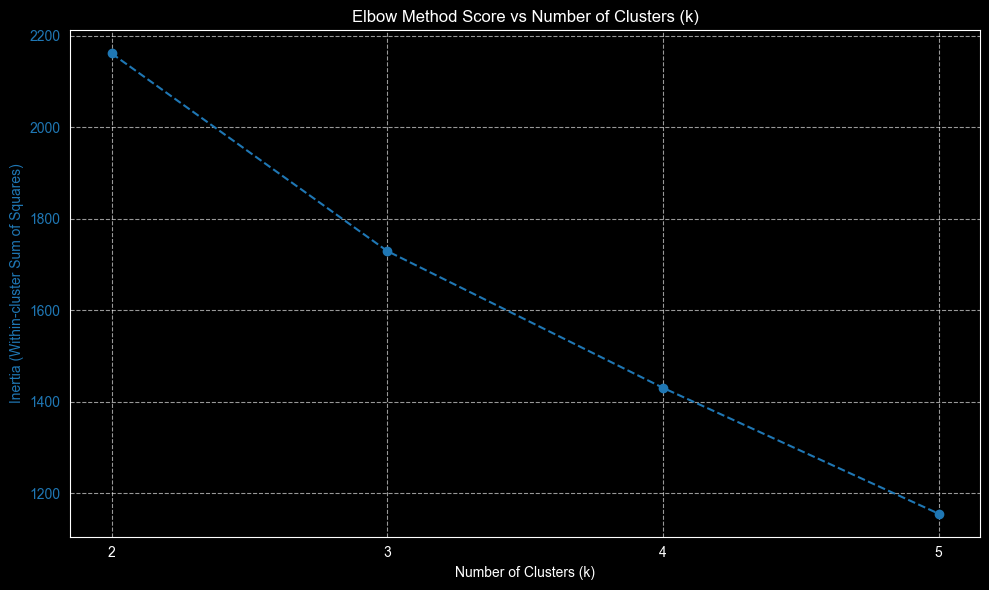

In [7]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot Inertia (Elbow Method)
color = 'tab:blue'
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia (Within-cluster Sum of Squares)', color=color)
ax1.plot(k_values, [results[k]['inertia'] for k in k_values], marker='o', linestyle='--', color=color, label='Inertia')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle='--', alpha=0.6)

plt.title("Elbow Method Score vs Number of Clusters (k)")
fig.tight_layout()
plt.xticks(k_values)
plt.show()


#### 5.3 Best Cluster Visualization (Selected k)
Based on the elbow method and the visualizations above, we select $k=3$ as a reasonable number of clusters for this analysis. We show a larger plot for this specific configuration.

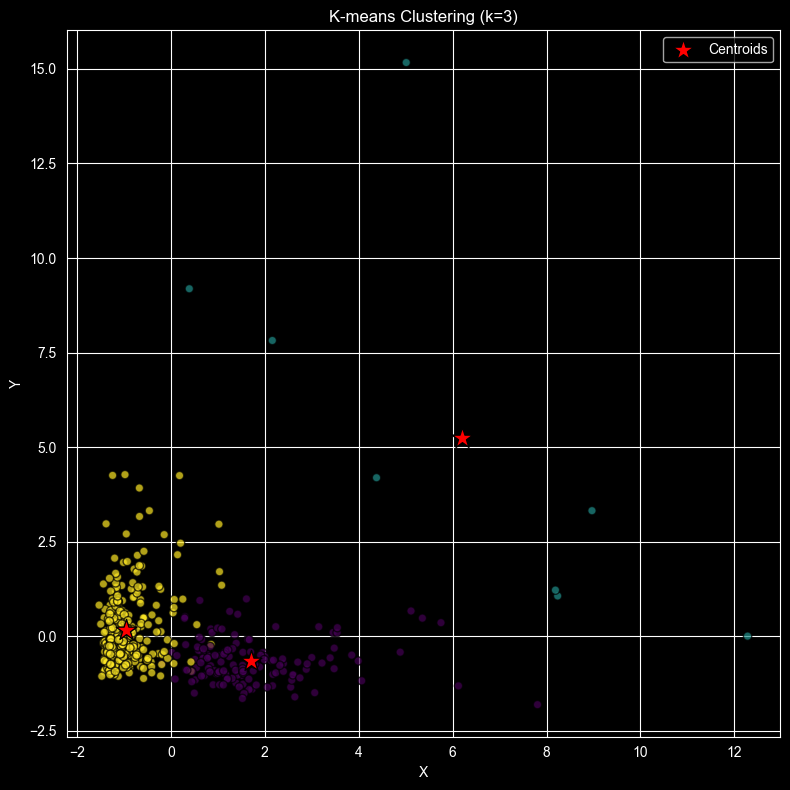

In [8]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(figsize=(8, 8))

# Select k
selected_k = 3

labels = results[selected_k]['labels']
centroids = results[selected_k]['centroids']

axes.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', marker='o', edgecolors='k', alpha=0.7)

# Project centroids to PCA space
centroids_pca = pca.transform(centroids)
axes.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
            s=250, marker='*', c='red', label='Centroids', edgecolors='black')

axes.set_title(f"K-means Clustering (k={selected_k})")
axes.set_xlabel("X")
axes.set_ylabel("Y")
axes.legend()

plt.tight_layout()
plt.show()


### 6. Analysis
The K-means algorithm was executed for $k \in \{2, 3, 4, 5\}$, each with 10 random initializations to avoid local minima. To select the optimal number of clusters, we used both the **Elbow Method**.

- **Elbow Method**: The inertia (within-cluster sum of squares) decreases as $k$ increases. The most significant drop occurs between $k=1$ (not shown) and $k=2$, with a noticeable "elbow" at **$k=3$**, after which the rate of decrease slows down.

We selected **$k=3$** for the final visualization. This choice is justified because it sits at the "elbow" of the inertia plot, providing a balanced compromise between model simplicity and effective segmentation of the wholesale customers.


### 7. Final Report
The following table summarizes the key metrics for our selected model. The centroids have been transformed back to the original feature space for better interpretability.

In [10]:
selected_results = results[selected_k]
original_centroids = scaler.inverse_transform(selected_results['centroids'])
original_centroids_df = pd.DataFrame(original_centroids, columns=X.columns)

print(f"--- Final Report (Selected k={selected_k}) ---")
print(f"Inertia: {selected_results['inertia']:.4f}")
print(f"Number of Iterations: {selected_results['n_iter']}")
print("\nFinal Centroids (Original Feature Space):")
print(original_centroids_df)


--- Final Report (Selected k=3) ---
Inertia: 1729.5107
Number of Iterations: 8

Final Centroids (Original Feature Space):
    Channel         Fresh          Milk       Grocery        Frozen  \
0  2.000000   7867.325926   9393.518519  15170.851852   1507.740741   
1  1.625000  40942.250000  42388.375000  39253.250000  16543.875000   
2  1.006734  13099.340067   3175.505051   3826.501684   3420.047138   

   Detergents_Paper    Delicassen  
0       6780.066667   1588.259259  
1      15320.625000  11369.250000  
2        774.353535   1230.888889  


In [ ]:
selected_results = results[selected_k]
original_centroids = scaler.inverse_transform(selected_results['centroids'])
original_centroids_df = pd.DataFrame(original_centroids, columns=X.columns)

print(f"--- Final Report (Selected k={selected_k}) ---")
print(f"Inertia: {selected_results['inertia']:.4f}")
print(f"Silhouette Score: {selected_results['silhouette']:.4f}")
print(f"Number of Iterations: {selected_results['n_iter']}")
print("\nFinal Centroids (Original Feature Space):")
print(original_centroids_df)
